# AP 155 Lab Exercise
---
## Exercise 6: Matrices

_Instructions_: 
- **Report figure:** (See step 5 of the problem)
- **Report discussion:**
  - Explain the pattern shown in the report figure. 
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Baculo, Ezira Lojelle
- _Student No._: 2024-11845
- _Section_: THR-TX-3

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure

<!-- <img src="figures/cat.jpg" alt="Alt text" width=45%> <img src="figures/cat.jpg" alt="Alt text" width=45%> -->

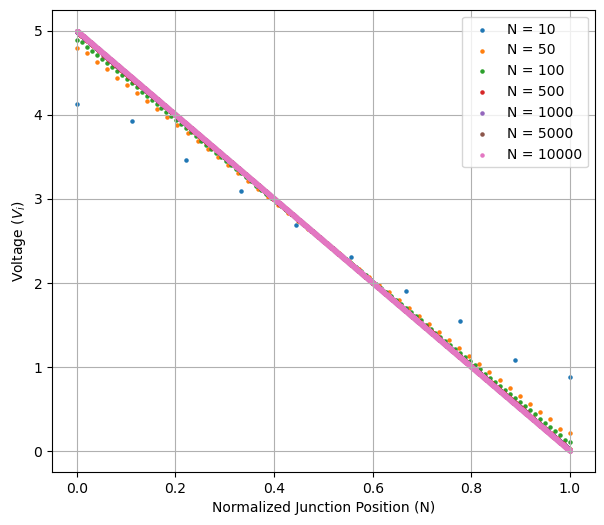

In [64]:
fig

#### Figure 1. Distribution of junction voltages ($V_i$) relative to their normalized junction position ($N$) across the ladder network, shown for $N = 10$ through $10,000$ at $V_+ = 5$ V.

### Report discussion

Creating the circuit model through Kirchhoff’s and Ohm’s laws results in a 5-diagonal banded linear system featuring an interior coefficient arrangement of $-1, -1, 4, -1, -1$. For $N = 6$, using `np.linalg.solve` results in junction voltages that drop from $3.73 V$ to $1.27 V$, staying within the anticipated $0–5 V$ physical range.


For $N = 1000$, building a complete dense matrix is not efficient in terms of computation. Employing `scipy.linalg.solve_banded` maintains the five-diagonal format, significantly lowering both memory usage and processing duration [1]. The voltages obtained range from about $0.001 V$ to $5.000 V$, with a central value of $2.50 V$


As $N$ rises from $10$ to $10000$, the discrete voltage profile increasingly smooths out, approaching a continuous, linear voltage drop throughout the network. Overall, the results validate anticipated circuit physics and emphasize the importance of choosing structure-aware numerical solvers for scalable computational modeling.

### Reference:

[1] Solve_banded — SciPy V1.15.2 manual. (2025). Scipy.Org. https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.solve_banded.html


### Other comments
- I don't like matrices fr fr.
- I asked another Physics major friend for guidance and checking.
- Sir, hindi ko po na-figure out kung paano gamitin yung `banded.py` kaya ang ginamit ko po ay yung `solve_banded` ng SciPy. 
- Note to self: Sana kaya pa nyehehe. (insert eye emoji)

#### Disclosure of AI Use:

I acknowledge the use of Gemini (accessed September 2026) to generate a first draft of the algorithms in numbers 4 and 5 to use `solve_banded` instead of `banded.py`. All AI-assisted suggestions were reviewed and revised with the help of the references provided and researched to ensure accuracy and clarity of meaning.

---
## Section 2: Code

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.linalg import *

### Problem: Circuit Analysis

1. **Using Ohm's law and the Kirchhoff current law**, which says that the total net current flow out of (or into) any junction in a circuit must be zero, show that the voltages $V_1\ldots V_N$ satisfy the equations

$$3V_1 - V_2 - V_3 = V_+ $$
$$-V_1 + 4V_2 - V_3 - V_4 = V_+ $$
$$ \vdots$$
$$-V_{i-2} - V_{i-1} + 4V_i - V_{i+1} - V_{i+2} = 0 $$
$$\vdots$$
$$-V_{N-3} - V_{N-2} + 4V_{N-1} - V_N = 0$$
$$-V_{N-2} - V_{N-1} + 3V_N = 0$$

_Note: Do this by hand (no need for markdown output). You need $N \geq 5$ to see the complete pattern._ 

2. Express these equations in vector form $\mathbf{A}\mathbf{v} = \mathbf{w}$ and find the values of the matrix $\mathbf{A}$ and the vector $\mathbf{w}$. Write a program that generates the matrix $\mathbf{A}$ and vector $\mathbf{v}$ given the number of nodes $N$ and $V_+$.

In [4]:
def make_system(N, V_plus=5.0):
    """
    Construct the matrix A and the RHS vector w.
    """
    A = 4.0 * np.eye(N)

    # Set the four off-diagonal bands to -1
    A -= np.eye(N, k=1)
    A -= np.eye(N, k=-1)
    A -= np.eye(N, k=2)
    A -= np.eye(N, k=-2)

    # End-point diagonal coefficients
    A[0,0] = 3.0
    A[-1,-1] = 3.0

    # Then, the right-hand side
    w = np.zeros(N)
    w[:2] = V_plus

    return A, w

In [36]:
# For example:

A, w = make_system(5)

print(A)
print(w)

# Which should be the same as what you got in number 1

[[ 3. -1. -1.  0.  0.]
 [-1.  4. -1. -1.  0.]
 [-1. -1.  4. -1. -1.]
 [ 0. -1. -1.  4. -1.]
 [ 0.  0. -1. -1.  3.]]
[5. 5. 0. 0. 0.]


3. Write a program to solve for the values of the $V_i$ when there are $N=6$ internal junctions with unknown voltages. (Hint: All the values of $V_i$ should lie between zero and $5$ [V].  If they don't, something is wrong.)

In [9]:
# Internal junctions
N = 6
V_plus = 5.0

A, w = make_system(N, V_plus)
V = np.linalg.solve(A, w)

# Junction voltages
for i, voltage in enumerate(V, start=1):
    print(f"V{i} = {voltage:.6f} V")

V1 = 3.725490 V
V2 = 3.431373 V
V3 = 2.745098 V
V4 = 2.254902 V
V5 = 1.568627 V
V6 = 1.274510 V


4. Now repeat your calculation for the case where there are $N=10\,000$ internal junctions.  This part is slow standard tools like the `solve` function from `np.linalg`. To solve efficiently, you need to make use of the fact that the matrix $\mathbf{A}$ is banded (and use Newman's `banded.py`).

In [39]:
# Using solve_banded from SciPy

def make_banded_system(N, V_plus=5.0):
    """
    Construct the banded matrix A and the RHS vector w.
    """
    A = np.zeros((5, N))

    # Main diagonal
    A[2,:] = 4.0
    A[2,0] = 3.0
    A[2,-1] = 3.0

    # First upper and lower diagonals
    A[1,1:] = -1.0
    A[3,:-1] = -1.0

    # Second upper and lower diagonals
    A[0,2:] = -1.0
    A[4,:-2] = -1.0

    # Then, the right-hand side
    w = np.zeros(N)
    w[:2] = V_plus

    return A, w

# Get min and max voltages
N = 10_000
A, w = make_banded_system(N)

# 2 diagonals above and below main diagonal
V = solve_banded((2,2), A, w) 

print(f"Minimum voltage = {V.min():.6f} V")
print(f"Maximum voltage = {V.max():.6f} V")

Minimum voltage = 0.001118 V
Maximum voltage = 4.998882 V


5. Try different values of $N \in \{10, 50, 100, 500, 1000, 5000, 10000\}$. For each $N$, plot the junction voltage. Overlay all the curves on a single plot. What pattern do you see? Why?

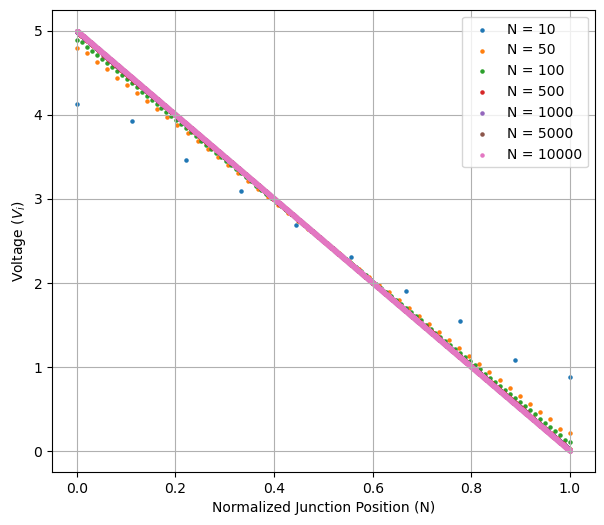

In [63]:
# Different values of N
Ns = [10, 50, 100, 500, 1000, 5000, 10000]
# Ns = [10000, 5000, 1000, 500, 50, 100, 10]

fig, ax = plt.subplots(figsize=(7, 6))

for N in Ns:
    # Create the banded matrix
    A = np.zeros((5, N))

    # Main diagonal
    A[2,:] = 4.0
    A[2,0] = 3.0
    A[2,-1] = 3.0

    # First upper and lower diagonals
    A[1,1:] = -1.0
    A[3,:-1] = -1.0

    # Second upper and lower diagonals
    A[0,2:] = -1.0
    A[4,:-2] = -1.0

    # Then, the right-hand side
    w = np.zeros(N)
    w[:2] = 5.0

    # Solve the banded system
    V = solve_banded((2, 2), A, w)

    # Normalize position so all curves can be compared
    x = np.linspace(0, 1, N)

    ax.scatter(x, V, label=f"N = {N}", s=5)

ax.set(xlabel='Normalized Junction Position (N)', ylabel='Voltage ($V_i$)')
ax.legend()
ax.grid(True)
plt.show()

As $(N)$ increases, the voltage curves become smoother and increasingly approach a nearly straight-line decrease from the higher voltage at the left side toward the lower voltage at the right side.

This happens because the interior junction equation:

$$ -V_{i-2} - V_{i-1} + 4V_i - V_{i+1} - V_{i+2} = 0 $$

produces a nearly linear voltage profile from the boundaries. Since

$$ V''(x)\approx0, $$

the continuous voltage profile approaches a linear function. With more junctions, the boundary effects become smaller relative to the total length, so the curves increasingly resemble a straight line.

#### Problem code summary

This program creates the voltage system as a five-diagonal banded matrix because each junction voltage is only connected to its two nearest and two next-nearest neighbors. In order to avoid storing and solving a large dense matrix, Newman's banded algorithm is used for $(N=10000)$ and `np.linalg.solve` for the small $(N=6)$ system.

---
## Section 3 (Notes)

### Some codes for solving matrix problems

* solving matrix equations ($\bf{A}\vec{x} = \vec{b}$) -> `np.linalg.solve`
* LU-decomposition ($\bf{A} = \bf{L}\bf{U}$) -> `scipy.linalg.lu`
* matrix inversion ($\bf{A}^{-1}$) -> `np.linalg.inv`
* QR-decomposition ($\bf{A} = \bf{Q}\bf{R}$) -> `scipy.linalg.qr`
* eigenvalue problem ($\bf{A}\vec{x} = \lambda \vec{x}$) -> `np.linalg.eig`

Solving matrix problems by themselves isn't difficult. There is an abundance of linear algebra libraries that are ready to use: from the battle-tested ones (the classic [BLAS](https://www.netlib.org/blas/) and [LAPACK](https://www.netlib.org/lapack/)), HPC tools for large problems ([ScaLAPACK](https://netlib.org/scalapack/)), to hardware-accelerated ones often with GPUs ([cuBLAS](https://docs.nvidia.com/cuda/cublas/index.html) and [cuSolver](https://docs.nvidia.com/cuda/cusolver/index.html) for NVIDIA). 

The hardest part is actually composing the matrix. How do you transform a physical problem into a linear algebra problem?

* Circuit: https://personal.math.vt.edu/embree/cmda3606/chapter2.pdf
* Embree [main notes](https://personal.math.vt.edu/embree/cmda3606notes.pdf) + [lab manual](https://personal.math.vt.edu/embree/labman.pdf)

#### Sample Usage

In [2]:
A = np.array([[1,0,2],[-2,-1,3],[0,3,5]])
B = np.array([[-2],[1],[-3]])

# Known: A@B == C
A@B

array([[ -8],
       [ -6],
       [-12]])

In [3]:
sigma_z = np.array([[1,0],[0,-1]])
sigma_y = np.array([[0,-1j],[1j,0]])
sigma_x = np.array([[0,1],[1,0]])

In [4]:
ans1 = np.linalg.solve(sigma_x, sigma_y) # sigma_x @ ___ = sigma_y
ans2 = np.linalg.inv(A) @ B
print(ans1)
print(ans2)

[[0.+1.j 0.+0.j]
 [0.+0.j 0.-1.j]]
[[-1.07692308]
 [-0.23076923]
 [-0.46153846]]


In [5]:
from scipy.linalg import *
p, l, u = lu(A) 
# A = original matrix
# p = permutation matrix
# l = lower triangular of A
# u = upper triangular of A
A, p, l, u

(array([[ 1,  0,  2],
        [-2, -1,  3],
        [ 0,  3,  5]]),
 array([[0., 0., 1.],
        [1., 0., 0.],
        [0., 1., 0.]]),
 array([[ 1.        ,  0.        ,  0.        ],
        [-0.        ,  1.        ,  0.        ],
        [-0.5       , -0.16666667,  1.        ]]),
 array([[-2.        , -1.        ,  3.        ],
        [ 0.        ,  3.        ,  5.        ],
        [ 0.        ,  0.        ,  4.33333333]]))

### Sample Problem

Suppose you have a hanging mass M supported by two ropes (angled by $\alpha$ and $\beta$ with respect to the ceiling). Make a function that calculates the tension on each of the ropes. 


Newton's Laws Equation:
$$T_A\sin(\alpha) + T_B\sin(\beta) = Mg $$
$$T_A\cos(\alpha) - T_B\cos(\beta) = 0 $$


In [6]:
alpha = np.pi/6
beta = np.pi/3
M = 100/9.81
g = 9.81

A = np.array([
    [np.sin(alpha), np.sin(beta)],
    [np.cos(alpha), -np.cos(beta)]
])
w = np.array([[M*g], [0]])

np.linalg.solve(A,w)

array([[50.        ],
       [86.60254038]])

### np.roll

In [7]:
## Useful tips. Not required to solve the problems below!

# Suppose you have a Numpy array
x = np.zeros((4,4))
for row in x:
    print(row)

#rint(x[0,1:3])


# I can move all values to the left/right using roll
x_roll = np.roll(x, 1) # change 1 to -1, what happens? 
#x_roll2 = np.roll(x, -1)
print(x_roll)



[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


### Example of an Undetermined System

Masses $m_1, m_2, m_3$, and $m_4$ lie on a $2.00$ [m] beam of negligible mass. They are located $0.20, 0.70, 1.10$, and $1.40$ [m] away from the left end of the beam. Determine the masses $m_1, m_2, m_3$, and $m_4$, given the following constraints: 

- The total mass is $8.00$ [kg]
- If a pivot is placed halfway, the beam will balance if a $1.05$ [kg] mass is placed on the right-end of the beam
- If a pivot is placed $1.20$ [m] away from the right end, then the beam would balance if a $0.550$ [N m] torque were applied on the left end of the beam.
- If the system is split midway, the total mass on the left is $1.00$ [kg] heavier than the total mass on the right

In [8]:
#The matrix A and vector b (in Ax = b) would be:
b = [8, 1.05, -0.550, 1.00]
A = np.array([
    [1,1,1,1],
    [0.8,0.3,-0.1,-0.4],
    [0.6,0.1,-0.3,-0.6],
    [1,1,-1,-1]
])

In [9]:
np.linalg.matrix_rank(A), np.shape(A)[0]

(3, 4)

The rank is less than the number of rows
This is because in matrix A, the third row is a linear combination of the first two rows $(A_3 = A_2 - 0.2(A_1))$. Hence, this is an undetermined system (or could be an impossible system if the 2nd and 3rd condition cannot be satisfied at the same time).

What if we changed the problem: Suppose the 3rd condition (3rd bullet point) is changed to:

- *The mass of $m_1$ is $1.00 [kg]$*

In [10]:
Anew = A.copy()
bnew = b.copy()
Anew[2], bnew[2] = [1,0,0,0], 1

In [11]:
np.linalg.solve(Anew,bnew)

array([1. , 3.5, 2. , 1.5])